In [1]:
import tensorflow as tf
print(tf.__version__)

2025-07-08 10:59:46.754336: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751972386.945653      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751972386.999649      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2.18.0


import lib

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
import glob as gb
import cv2
from pathlib import Path

**Reading data**

In [3]:
data_path = Path('/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)')
image_path = data_path / 'New Plant Diseases Dataset(Augmented)'
train_dir = image_path/'train/'
valid_dir = image_path/'valid/'
test_dir = Path("/kaggle/input/new-plant-diseases-dataset/test/test/")

diseases = os.listdir(train_dir)
print(diseases)

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato___Leaf_Mold', 'Tomato__

EDA

In [4]:
for folder in os.listdir(train_dir):
    print(folder)
    
    file=gb.glob(pathname=str(train_dir/folder/'*'))
    print(len(file))

Tomato___Late_blight
1851
Tomato___healthy
1926
Grape___healthy
1692
Orange___Haunglongbing_(Citrus_greening)
2010
Soybean___healthy
2022
Squash___Powdery_mildew
1736
Potato___healthy
1824
Corn_(maize)___Northern_Leaf_Blight
1908
Tomato___Early_blight
1920
Tomato___Septoria_leaf_spot
1745
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
1642
Strawberry___Leaf_scorch
1774
Peach___healthy
1728
Apple___Apple_scab
2016
Tomato___Tomato_Yellow_Leaf_Curl_Virus
1961
Tomato___Bacterial_spot
1702
Apple___Black_rot
1987
Blueberry___healthy
1816
Cherry_(including_sour)___Powdery_mildew
1683
Peach___Bacterial_spot
1838
Apple___Cedar_apple_rust
1760
Tomato___Target_Spot
1827
Pepper,_bell___healthy
1988
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
1722
Potato___Late_blight
1939
Tomato___Tomato_mosaic_virus
1790
Strawberry___healthy
1824
Apple___healthy
2008
Grape___Black_rot
1888
Potato___Early_blight
1939
Cherry_(including_sour)___healthy
1826
Corn_(maize)___Common_rust_
1907
Grape___Esca_(Black_Mea

In [5]:
for folder in os.listdir(valid_dir):
    print(folder)
    
    file=gb.glob(pathname=str(valid_dir/folder/'*'))
    print(len(file))

Tomato___Late_blight
463
Tomato___healthy
481
Grape___healthy
423
Orange___Haunglongbing_(Citrus_greening)
503
Soybean___healthy
505
Squash___Powdery_mildew
434
Potato___healthy
456
Corn_(maize)___Northern_Leaf_Blight
477
Tomato___Early_blight
480
Tomato___Septoria_leaf_spot
436
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
410
Strawberry___Leaf_scorch
444
Peach___healthy
432
Apple___Apple_scab
504
Tomato___Tomato_Yellow_Leaf_Curl_Virus
490
Tomato___Bacterial_spot
425
Apple___Black_rot
497
Blueberry___healthy
454
Cherry_(including_sour)___Powdery_mildew
421
Peach___Bacterial_spot
459
Apple___Cedar_apple_rust
440
Tomato___Target_Spot
457
Pepper,_bell___healthy
497
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
430
Potato___Late_blight
485
Tomato___Tomato_mosaic_virus
448
Strawberry___healthy
456
Apple___healthy
502
Grape___Black_rot
472
Potato___Early_blight
485
Cherry_(including_sour)___healthy
456
Corn_(maize)___Common_rust_
477
Grape___Esca_(Black_Measles)
480
Raspberry___healthy
44

In [6]:
    file=gb.glob(pathname=str(test_dir/'*'))
    print(len(file))

33


In [7]:

size=[]
for folder in os.listdir(train_dir):
    #print(folder)
    
    file=gb.glob(pathname=str(train_dir/folder/'*'))
    #print(len(file))
    for image in file:
        img=plt.imread(image)
        size.append(img.shape)
     

In [8]:
pd.Series(size).value_counts()

(256, 256, 3)    70295
Name: count, dtype: int64

In [9]:

size=[]
for folder in os.listdir(valid_dir):
    #print(folder)
    
    file=gb.glob(pathname=str(valid_dir/folder/'*'))
    #print(len(file))
    for image in file:
        img=plt.imread(image)
        size.append(img.shape) 


In [10]:
pd.Series(size).value_counts()

(256, 256, 3)    17572
Name: count, dtype: int64

In [11]:

size=[]
file=gb.glob(pathname=str(test_dir/'*'))
for image in file:
    img=plt.imread(image)
    size.append(img.shape) 
pd.Series(size).value_counts()    


(256, 256, 3)    33
Name: count, dtype: int64

**PREPROCCESSING**

In [12]:
code = {
    'Tomato___Late_blight': 0,
    'Tomato___healthy': 1,
    'Grape___healthy': 2,
    'Orange___Haunglongbing_(Citrus_greening)': 3,
    'Soybean___healthy': 4,
    'Squash___Powdery_mildew': 5,
    'Potato___healthy': 6,
    'Corn_(maize)___Northern_Leaf_Blight': 7,
    'Tomato___Early_blight': 8,
    'Tomato___Septoria_leaf_spot': 9,
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 10,
    'Strawberry___Leaf_scorch': 11,
    'Peach___healthy': 12,
    'Apple___Apple_scab': 13,
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 14,
    'Tomato___Bacterial_spot': 15,
    'Apple___Black_rot': 16,
    'Blueberry___healthy': 17,
    'Cherry_(including_sour)___Powdery_mildew': 18,
    'Peach___Bacterial_spot': 19,
    'Apple___Cedar_apple_rust': 20,
    'Tomato___Target_Spot': 21,
    'Pepper,_bell___healthy': 22,
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 23,
    'Potato___Late_blight': 24,
    'Tomato___Tomato_mosaic_virus': 25,
    'Strawberry___healthy': 26,
    'Apple___healthy': 27,
    'Grape___Black_rot': 28,
    'Potato___Early_blight': 29,
    'Cherry_(including_sour)___healthy': 30,
    'Corn_(maize)___Common_rust_': 31,
    'Grape___Esca_(Black_Measles)': 32,
    'Raspberry___healthy': 33,
    'Tomato___Leaf_Mold': 34,
    'Tomato___Spider_mites Two-spotted_spider_mite': 35,
    'Pepper,_bell___Bacterial_spot': 36,
    'Corn_(maize)___healthy': 37
}

print(code)

{'Tomato___Late_blight': 0, 'Tomato___healthy': 1, 'Grape___healthy': 2, 'Orange___Haunglongbing_(Citrus_greening)': 3, 'Soybean___healthy': 4, 'Squash___Powdery_mildew': 5, 'Potato___healthy': 6, 'Corn_(maize)___Northern_Leaf_Blight': 7, 'Tomato___Early_blight': 8, 'Tomato___Septoria_leaf_spot': 9, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 10, 'Strawberry___Leaf_scorch': 11, 'Peach___healthy': 12, 'Apple___Apple_scab': 13, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 14, 'Tomato___Bacterial_spot': 15, 'Apple___Black_rot': 16, 'Blueberry___healthy': 17, 'Cherry_(including_sour)___Powdery_mildew': 18, 'Peach___Bacterial_spot': 19, 'Apple___Cedar_apple_rust': 20, 'Tomato___Target_Spot': 21, 'Pepper,_bell___healthy': 22, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 23, 'Potato___Late_blight': 24, 'Tomato___Tomato_mosaic_virus': 25, 'Strawberry___healthy': 26, 'Apple___healthy': 27, 'Grape___Black_rot': 28, 'Potato___Early_blight': 29, 'Cherry_(including_sour)___healthy': 30, 'Co

In [13]:
def getcode(n):
    for x,y in code.items():
        if n==y:
            return x


In [14]:
getcode(2)

'Grape___healthy'

In [15]:
x_train=[]
y_train=[]
for folder in os.listdir(train_dir):
    #print(folder)
    
    file=gb.glob(pathname=str(train_dir/folder/'*'))
    #print(len(file))
    for image in file:
        img=cv2.imread(image)
        resized_img=cv2.resize(img,(160,160))
        x_train.append(resized_img)
        y_train.append(code[folder])

In [16]:
set(y_train)

{0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37}

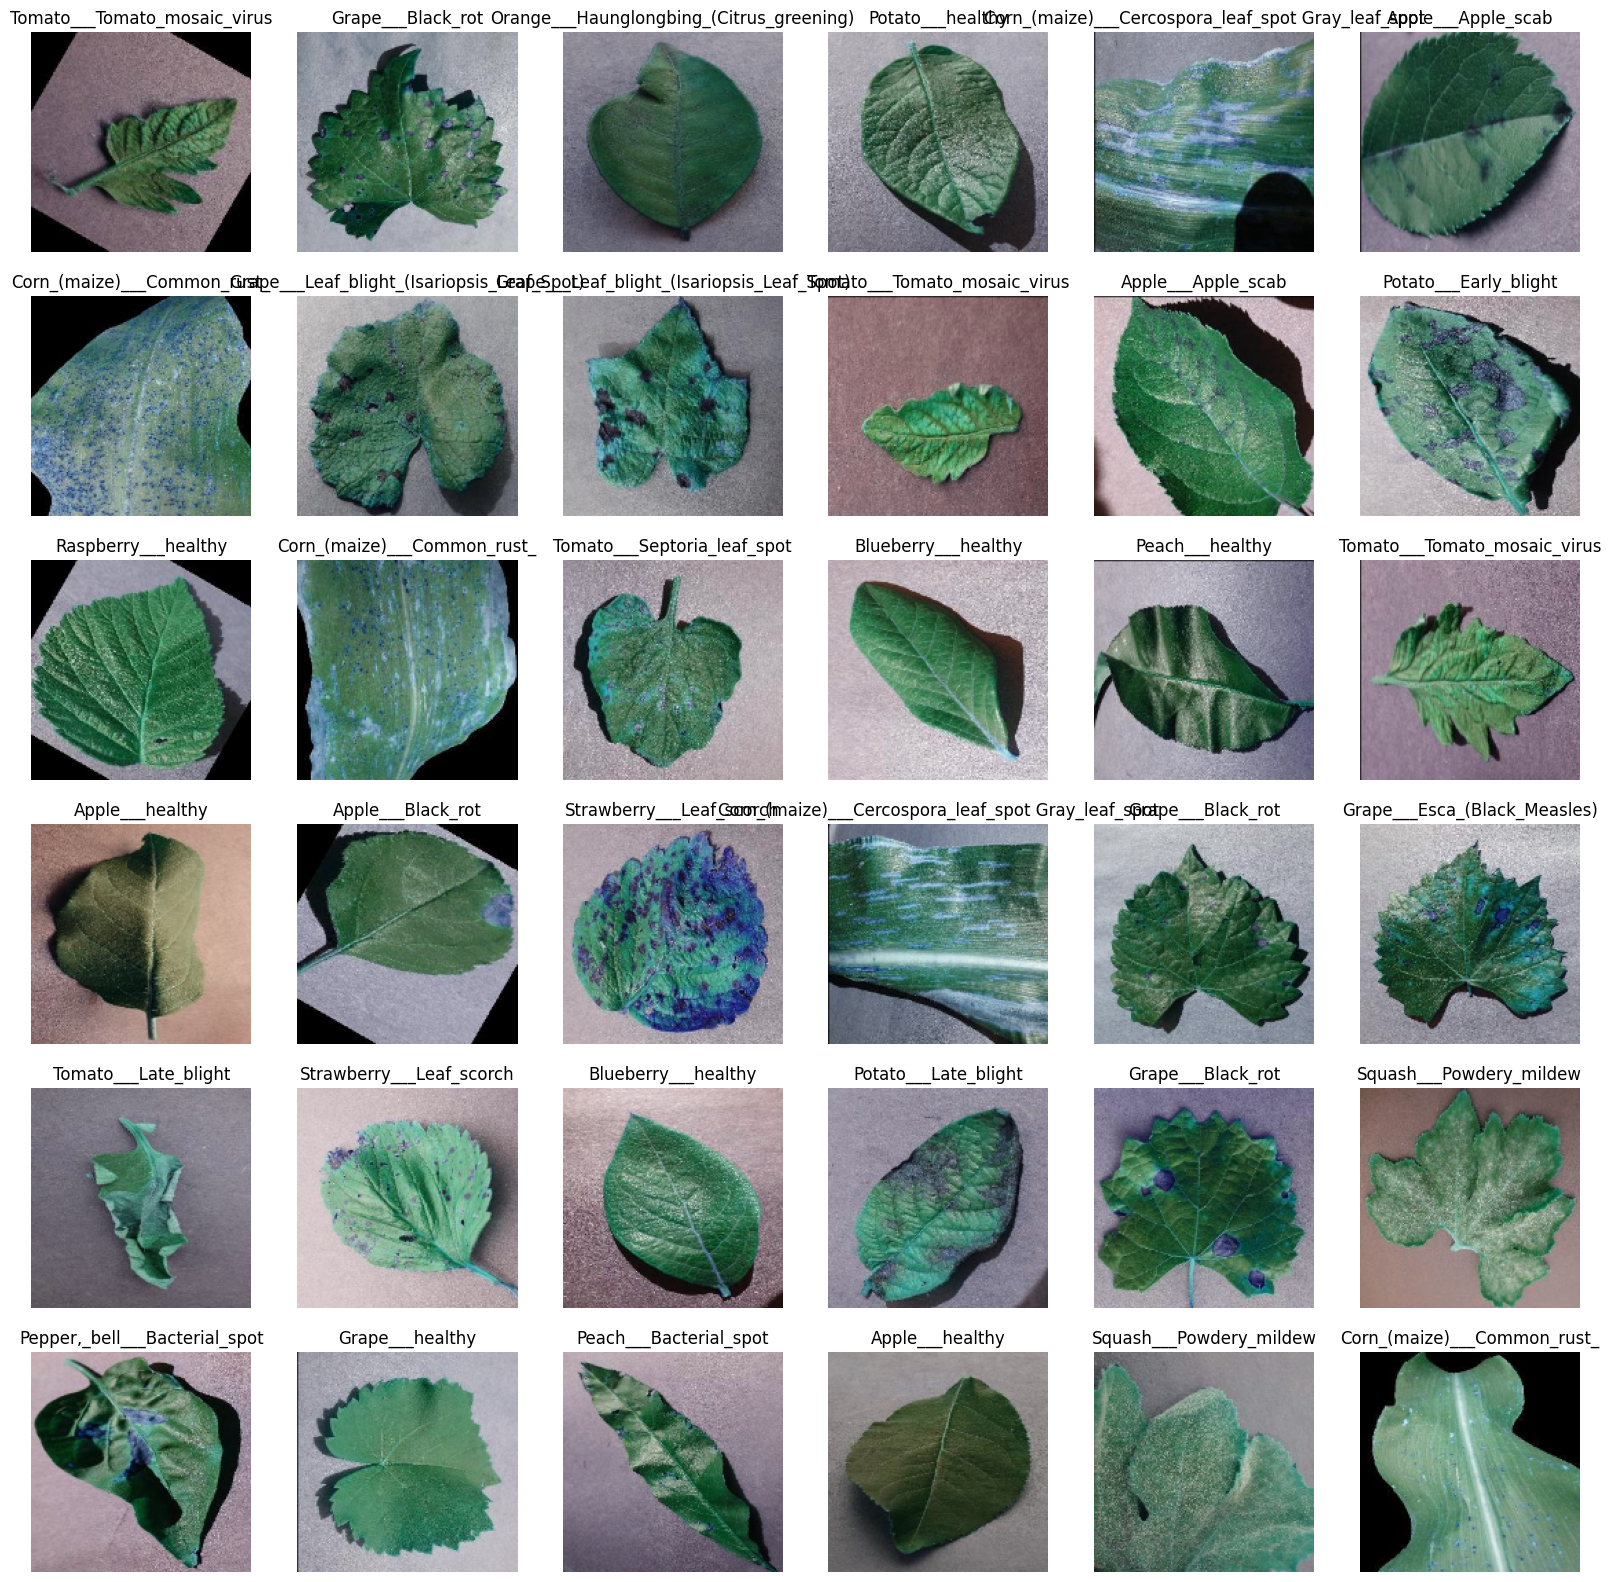

In [17]:
plt.figure(figsize=(20,20))

for n,i in enumerate(list(np.random.randint(0,len(x_train),36))) :
    plt.subplot(6,6,n+1)
    plt.imshow(x_train[i])
    plt.axis("off")
    plt.title(getcode(y_train[i]))
   

In [18]:
x_test=[]
y_test=[]
for folder in os.listdir(valid_dir):
    #print(folder)
    
    file=gb.glob(pathname=str(valid_dir/folder/'*'))
    #print(len(file))
    for image in file:
        img=cv2.imread(image)
        resized_img=cv2.resize(img,(160,160))
        x_test.append(resized_img)
        y_test.append(code[folder])

In [19]:
set(y_test)

{0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37}

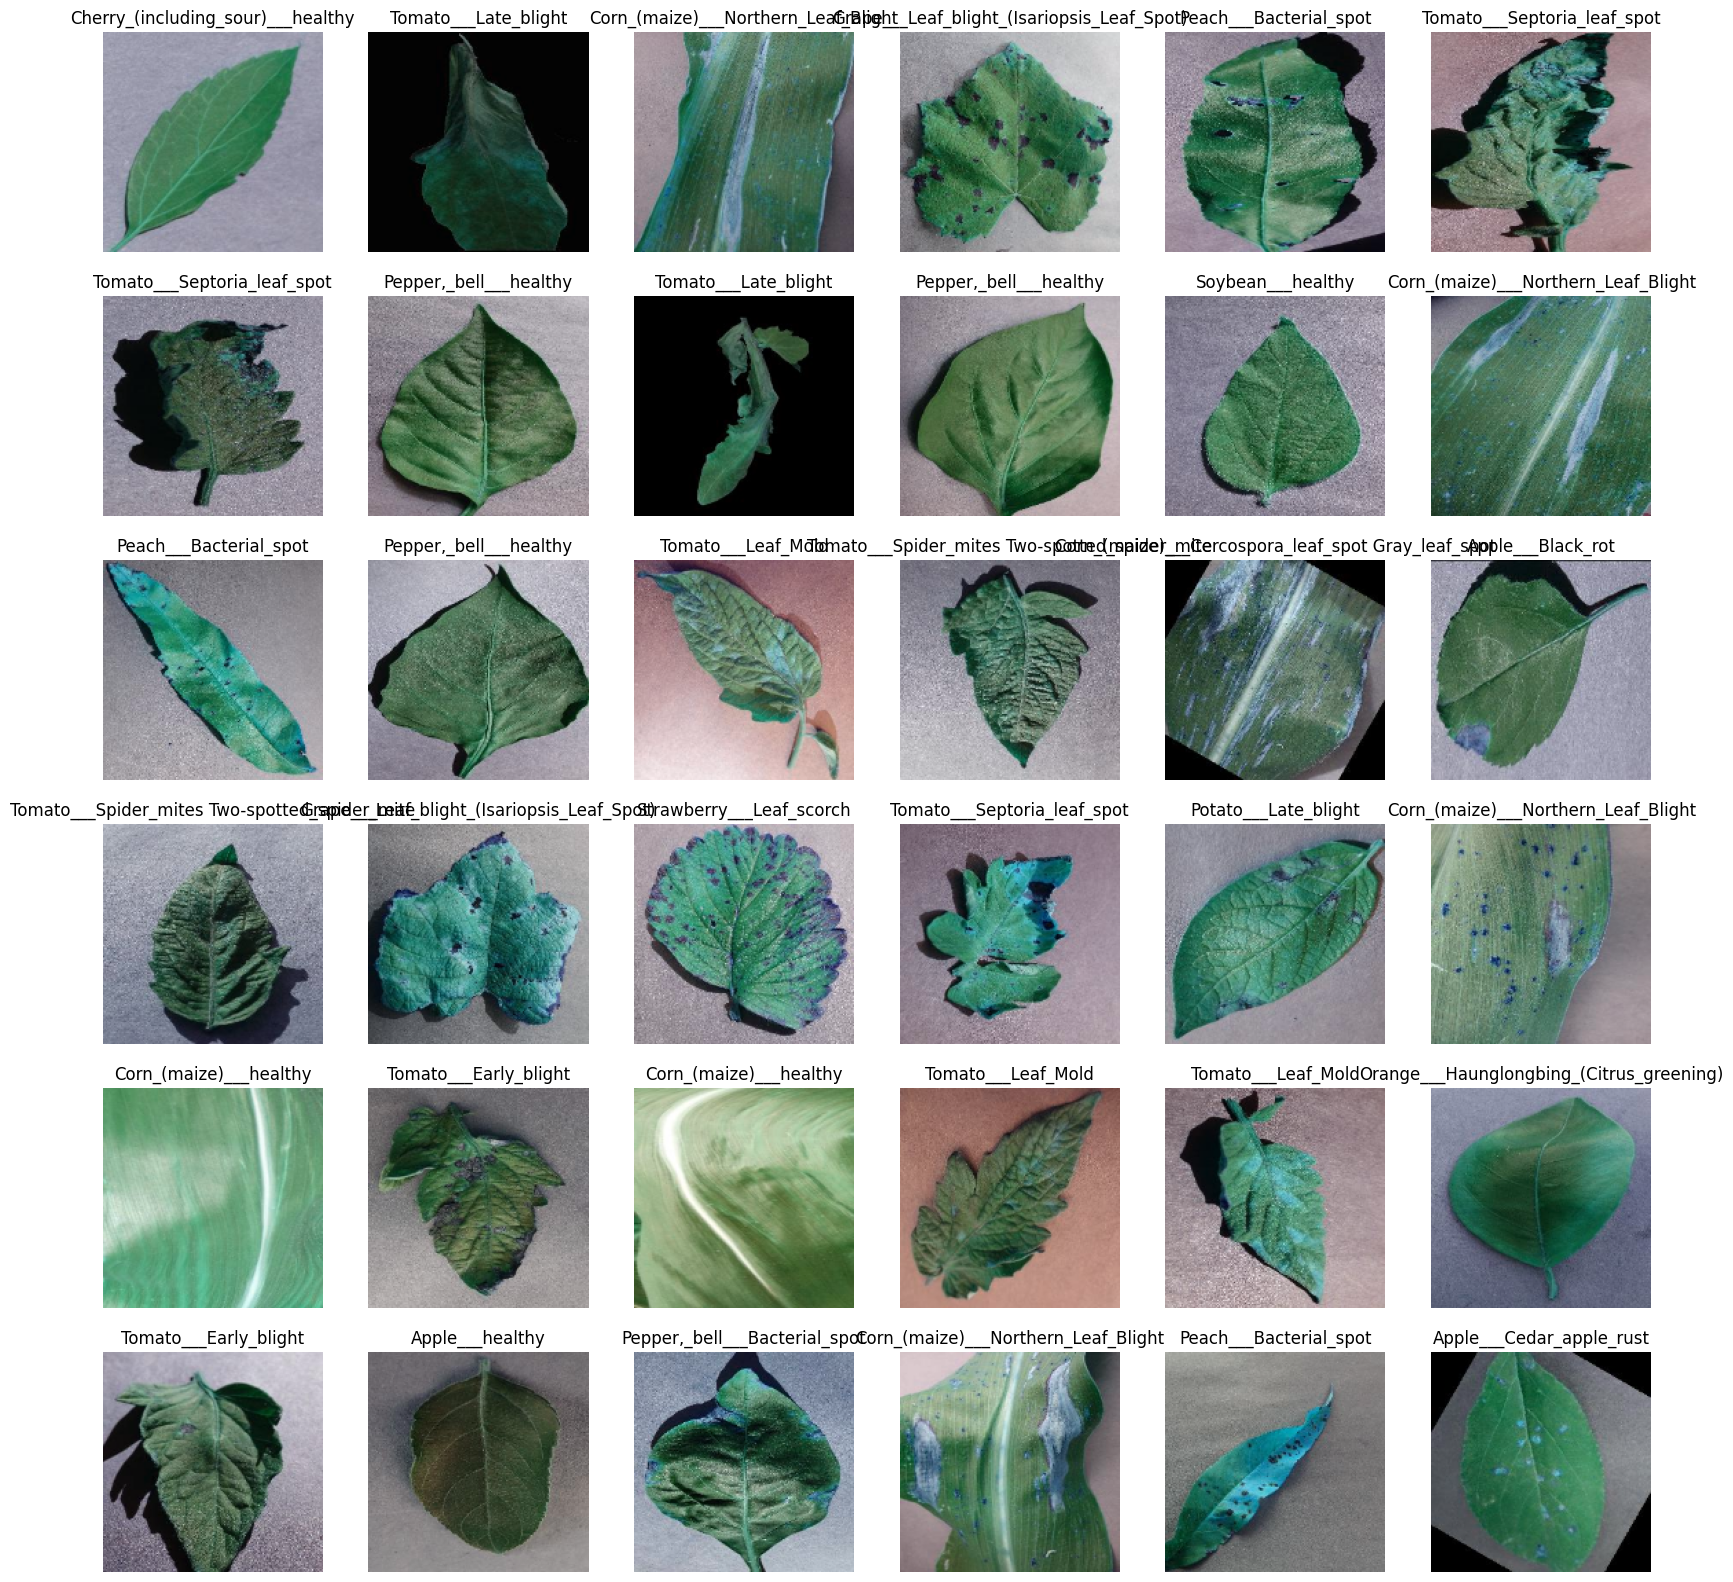

In [20]:
plt.figure(figsize=(20,20))

for n,i in enumerate(list(np.random.randint(0,len(x_test),36))) :
    plt.subplot(6,6,n+1)
    plt.imshow(x_test[i])
    plt.axis("off")
    plt.title(getcode(y_test[i]))

In [21]:
x_pred=[]


file=gb.glob(pathname=str(test_dir/'*')) 
print(len(file))
for image in file:
    img=cv2.imread(image)
    resized_img=cv2.resize(img,(160,160))
    x_pred.append(resized_img)
    
    

33


In [22]:
len(x_pred)


33

In [23]:
x_train=np.array(x_train)
x_test=np.array(x_test)


y_train=np.array(y_train)
y_test=np.array(y_test)

x_pred=np.array(x_pred)

In [24]:
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


x_test: (17572, 160, 160, 3)
y_test: (17572,)


**Model Architecture**

In [25]:

model = keras.models.Sequential([

    keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(160, 160, 3)),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2, 2),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2, 2),

    keras.layers.Conv2D(256, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(256, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2, 2),

    keras.layers.Conv2D(512, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2, 2),

keras.layers.Flatten(),

keras.layers.Dense(512, activation='relu'),
keras.layers.BatchNormalization(),              
keras.layers.Dropout(0.2),

keras.layers.Dense(128, activation='relu'),
keras.layers.BatchNormalization(),             


keras.layers.Dense(38, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1751973391.039209      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 158, 158, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 158, 158, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 156, 156, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 156, 156, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 78, 78, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 76, 76, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 76, 76, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 74, 74, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 74, 74, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 35, 35, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 35, 35, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 33, 33, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 33, 33, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 14, 14, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 512)           │              

 Total params: 15,249,894 (58.17 MB)

 Trainable params: 15,245,798 (58.16 MB)

 Non-trainable params: 4,096 (16.00 KB)

In [27]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=False)

In [28]:
final=model.fit(x_train,y_train,epochs=25)

Epoch 1/25


I0000 00:00:1751973415.099890      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 336s 147ms/step - accuracy: 0.6503 - loss: 1.2147
Epoch 2/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 321s 146ms/step - accuracy: 0.9090 - loss: 0.2859
Epoch 3/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 321s 146ms/step - accuracy: 0.9472 - loss: 0.1573
Epoch 4/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 321s 146ms/step - accuracy: 0.9609 - loss: 0.1181
Epoch 5/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 321s 146ms/step - accuracy: 0.9719 - loss: 0.0854
Epoch 6/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 321s 146ms/step - accuracy: 0.9771 - loss: 0.0686
Epoch 7/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 321s 146ms/step - accuracy: 0.9833 - loss: 0.0497
Epoch 8/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 320s 146ms/step - accuracy: 0.9859 - loss: 0.0414
Epoch 9/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 321s 146ms/step - accuracy: 0.9879 - loss: 0.0352
Epoch 10/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 320s 146ms/step - accuracy: 0.9889 - loss: 0.0347
Epoch 11/25
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 320s 146ms/step - accuracy: 0.9907 - loss: 0.02

In [29]:
loss, acc = model.evaluate(x_test, y_test)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {loss:.4f}")


550/550 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.9852 - loss: 0.0652
Test Accuracy: 0.9868
Test Loss: 0.0515


In [30]:

train_loss, train_acc = model.evaluate(x_train, y_train)


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Training Loss: {train_loss:.4f}")


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.9993 - loss: 0.0028
Training Accuracy: 0.9994
Training Loss: 0.0024


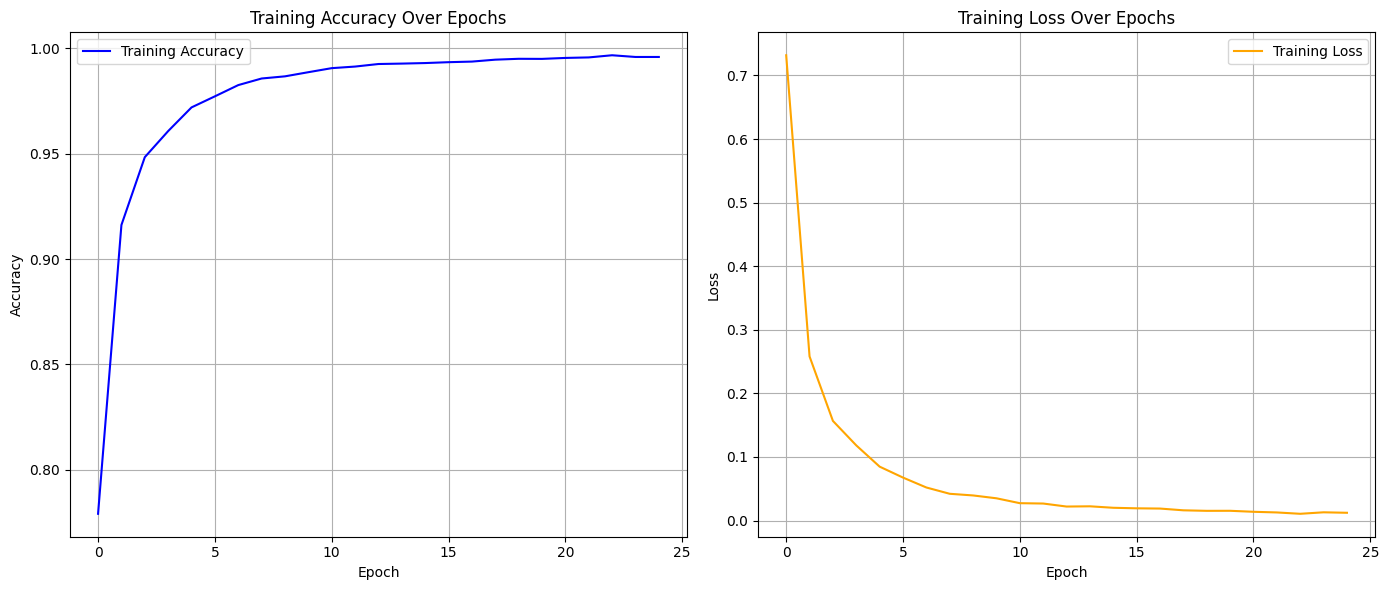

In [31]:

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(final.history['accuracy'], label='Training Accuracy', color='blue')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(final.history['loss'], label='Training Loss', color='orange')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [32]:
x_pred.shape

(33, 160, 160, 3)

In [33]:
predictions = model.predict(x_pred)
predicted_class = predictions.argmax()

print(predicted_class)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 470ms/step
52


In [34]:
for i in predictions:
    predicted_class = i.argmax()
    print(predicted_class)
    print(getcode(predicted_class))
    

8
Tomato___Early_blight
14
Tomato___Tomato_Yellow_Leaf_Curl_Virus
14
Tomato___Tomato_Yellow_Leaf_Curl_Virus
6
Potato___healthy
14
Tomato___Tomato_Yellow_Leaf_Curl_Virus
29
Potato___Early_blight
14
Tomato___Tomato_Yellow_Leaf_Curl_Virus
8
Tomato___Early_blight
31
Corn_(maize)___Common_rust_
13
Apple___Apple_scab
8
Tomato___Early_blight
1
Tomato___healthy
31
Corn_(maize)___Common_rust_
29
Potato___Early_blight
8
Tomato___Early_blight
14
Tomato___Tomato_Yellow_Leaf_Curl_Virus
31
Corn_(maize)___Common_rust_
8
Tomato___Early_blight
20
Apple___Cedar_apple_rust
1
Tomato___healthy
13
Apple___Apple_scab
1
Tomato___healthy
13
Apple___Apple_scab
20
Apple___Cedar_apple_rust
6
Potato___healthy
14
Tomato___Tomato_Yellow_Leaf_Curl_Virus
29
Potato___Early_blight
20
Apple___Cedar_apple_rust
29
Potato___Early_blight
8
Tomato___Early_blight
20
Apple___Cedar_apple_rust
29
Potato___Early_blight
1
Tomato___healthy


In [35]:
import shutil
model.save("model.h5")
shutil.move('model.h5','/kaggle/working/model.h5')

'/kaggle/working/model.h5'